## Use of AI

The following sentences address the further use of AI, besides the necessary use of AI models required to complete the assignments. AI was used to aid me in completing the tasks throughout the assignment. In Task 0-2, AI was used more modestly, mainly to debug occasional errors and aid with code logic when I could not apply logic from existing documentation. In the completion Task 3, AI was more heavily leaned on, as the task was challenging and I used AI to elaborate on what the task is actually asking for, explain concepts, along with helping me generate, edit and debug my code. 

### Task 0

### a)

In [1]:
from dotenv import load_dotenv
import os
import requests

load_dotenv()

BASE_URL = os.getenv("OLLAMA_BASE_URL", "http://localhost:11434")
MODEL = os.getenv("OLLAMA_MODEL", "llama3")

### b)

In [2]:
from ollama import chat

response = chat(
    model='gemma3:270m',
    messages=[{'role': 'user', 'content': 'Give me a great pizza recipe'}],
)
print(response.message.content)

Okay, let's craft a fantastic pizza recipe! To give you the best suggestion, I need a little more information.  Tell me about:

*   **The type of pizza you'd like:** (e.g., thin crust, deep dish, New York style, etc.)
*   **The desired crust:** (e.g., thin, thick, sourdough, rustic, etc.)
*   **The desired toppings:** (e.g., cheese, meats, vegetables, etc.)
*   **Your preferred flavor profile:** (e.g., spicy, tangy, savory, sweet, etc.)
*   **Any dietary restrictions or preferences:** (e.g., vegetarian, gluten-free, vegan, low-carb, etc.)

Once I have this information, I can tailor the recipe to your specific needs.

In the meantime, here's a simple, classic pizza recipe that's easy to make:

**Classic Thin Crust Pizza**

This recipe uses a simple dough for a delicious result.

**Ingredients:**

*   1 ½ cups all-purpose flour, plus extra for dusting
*   1 teaspoon salt
*   ½ cup (1 stick) unsalted butter, softened
*   ¼ cup finely chopped fresh herbs (such as oregano, basil, or parsley

### c)

In [3]:
from ollama import chat

response = chat(
    model='gemma3:4b',
    messages=[{'role': 'user', 'content': 'Give me a great pasta recipe'}],
)
print(response.message.content)

## Creamy Lemon & Shrimp Pasta - A Crowd-Pleaser

This recipe is vibrant, flavorful, and surprisingly easy to make. It’s great for a weeknight dinner but feels fancy enough for company.

**Yields:** 4-6 servings
**Prep time:** 15 minutes
**Cook time:** 20-25 minutes


**Ingredients:**

* **Pasta:** 1 lb Linguine or Fettuccine (long, flat pasta works best)
* **Shrimp:** 1 lb Large Shrimp, peeled and deveined
* **Butter:** 4 tbsp Unsalted Butter
* **Garlic:** 4 cloves, minced
* **Lemon:** 1 large Lemon (zest and juice)
* **Chicken Broth:** 1 cup (low sodium preferred)
* **Heavy Cream:** 1/2 cup
* **Parmesan Cheese:** 1/2 cup, grated (plus more for serving)
* **Fresh Parsley:** 1/4 cup, chopped
* **Red Pepper Flakes:** 1/4 - 1/2 tsp (adjust to your spice preference)
* **Salt & Black Pepper:** To taste
* **Olive Oil:** 1 tbsp


**Instructions:**

1. **Cook the Pasta:** Bring a large pot of salted water to a boil. Add the pasta and cook according to package directions until al dente. Reserv

### Task 1

### a)

In [4]:
import pandas as pd

#importing df and making sure it parses correctly by skipping the first row, giving the columns descriptive names
df = pd.read_csv("emails.csv", header=None, names=["Headline", "Text"], skiprows=1)

#new clean dataframe for task 1 d):
task1d_df = df

display(df)

,Headline,Text
0,URGENT: Your account will be suspended within ...,NaN
1,Congratulations! You have won a 1000€ gift card,claim now
2,Hot singles in your area are waiting to meet y...,NaN
3,Re: Inheritance transfer of 4.5M USD pending y...,NaN
4,Meeting agenda for Thursday's project review,NaN
5,Q3 budget report attached,please review by Friday
6,Reminder: Annual performance review scheduled ...,NaN
7,Updated draft of the manuscript,comments welcome
8,Quick question about last week,NaN
9,Following up,NaN


In [5]:
from openai import OpenAI

client = OpenAI(
    base_url="http://localhost:11434/v1/",
    api_key="ollama"
)

def ask_llm(prompt):
    response = client.chat.completions.create(
        model=MODEL,
        messages=[{"role": "user", "content": prompt}]
    )
    return response.choices[0].message.content

In [6]:
#creating the categorization function that takes a parameter text, giving a prompt to the llm
def categorize_email(text):
    prompt = (
        f"Classify the headline of the following email as exactly one word, no explanation, use only one of the following categories for each headline: "
        f"Work, Spam, or Unknown.\n\n"
        f"Review: {text}"
    )
    result = ask_llm(prompt).strip()
    return result

### b)

In [7]:
#calling the categorization function on the email dataframe
MODEL = "gemma3:270m"

df["Category"] = df["Headline"].apply(categorize_email)
display(df)

,Headline,Text,Category
0,URGENT: Your account will be suspended within ...,NaN,Work
1,Congratulations! You have won a 1000€ gift card,claim now,Work
2,Hot singles in your area are waiting to meet y...,NaN,Email
3,Re: Inheritance transfer of 4.5M USD pending y...,NaN,Work
4,Meeting agenda for Thursday's project review,NaN,Work
5,Q3 budget report attached,please review by Friday,Email
6,Reminder: Annual performance review scheduled ...,NaN,Work
7,Updated draft of the manuscript,comments welcome,Review
8,Quick question about last week,NaN,Unlikely
9,Following up,NaN,Work


### c)

In [8]:
#using the gemma3 4b model
MODEL = "gemma3:4b"

df["Category"] = df["Headline"].apply(categorize_email)
display(df)

,Headline,Text,Category
0,URGENT: Your account will be suspended within ...,NaN,Spam
1,Congratulations! You have won a 1000€ gift card,claim now,Spam
2,Hot singles in your area are waiting to meet y...,NaN,Spam
3,Re: Inheritance transfer of 4.5M USD pending y...,NaN,Unknown
4,Meeting agenda for Thursday's project review,NaN,Work
5,Q3 budget report attached,please review by Friday,Work
6,Reminder: Annual performance review scheduled ...,NaN,Work
7,Updated draft of the manuscript,comments welcome,Work
8,Quick question about last week,NaN,Work
9,Following up,NaN,Work


When comparing the results generated by gemma3 (270m) and gemma3 (4b), it seems like the (4b) version succeeds much better with the task, as it follows the instructions better. The (270m) version wants to make up new categories, and not stick to the ones provided in the prompt. Additionally, the (270m) version failed to categorize the headlines correctly, as multiple headlines that clearly fall under the "Spam" category are labelled as "Work". 

### d)

In [9]:
for run in range(1, 4):
    MODEL = "gemma3:270m"
    task1d_df[f"Category (270m) run{run}"] = task1d_df["Headline"].apply(categorize_email)

    MODEL = "gemma3:4b"
    task1d_df[f"Category (4b) run{run}"] = task1d_df["Headline"].apply(categorize_email)
    
display(task1d_df)

,Headline,Text,Category,Category (270m) run1,Category (4b) run1,Category (270m) run2,Category (4b) run2,Category (270m) run3,Category (4b) run3
0,URGENT: Your account will be suspended within ...,NaN,Spam,Work,Work,Work,Work,Unlikely,Spam
1,Congratulations! You have won a 1000€ gift card,claim now,Spam,Work,Spam,Work,Spam,Work,Spam
2,Hot singles in your area are waiting to meet y...,NaN,Spam,Work,Spam,Work,Spam,Work,Spam
3,Re: Inheritance transfer of 4.5M USD pending y...,NaN,Unknown,Work,Unknown,Work,Unknown,Work,Unknown
4,Meeting agenda for Thursday's project review,NaN,Work,Review,Work,Work,Work,Work,Work
5,Q3 budget report attached,please review by Friday,Work,Email,Work,Work,Work,Uncategorized,Work
6,Reminder: Annual performance review scheduled ...,NaN,Work,Work,Work,Work,Work,Work,Work
7,Updated draft of the manuscript,comments welcome,Work,Review,Work,Review,Work,Work,Work
8,Quick question about last week,NaN,Work,Review,Work,Work,Work,Work,Work
9,Following up,NaN,Work,Review,Work,Work,Work,Work,Work


After running both the models 3 times, it is clear that 4b is significantly better suited for the task. The 4b model not only followed the instructions provided in the prompt successfully, but also managed to categorize the emails correctly. The 270m model did not follow instructions, nor did it manage to classify the emails correctly. Furthermore, the 270m model showed variation in results across the 3 runs. This happens because the 270m model is a very small LLM compared to the 4b model, as the name tells us. The 270m model has approx 270 million parameters, while the 4b model has approx 4 billion, meaning it has a much larger capacity to learn patterns.

### Task 2

### a) & b)
The following cells solve task 2 a) & b) simultaneously, as the function for task 2 a) uses variables defined in the ask_llm2 function for task 2 b), which is why the order of cells might lead to some confusion. 

In [10]:
news_df = pd.read_csv("news.csv", header=None, names=["Headline", "Text"], skiprows=1)

display(news_df)

,Headline,Text
0,Nordion Industries beats Q1 earnings estimates...,NaN
1,Helvora Pharmaceuticals misses earnings foreca...,NaN
2,Aurelis Bank reports steady quarterly profit,in line with analyst expectations
3,Veridyne Logistics to acquire rival Trantec in...,NaN
4,Antitrust regulators block proposed merger bet...,NaN
5,Kestrel Semiconductor confirms early-stage mer...,NaN
6,New EU AI Act compliance rules expected to rai...,NaN
7,Finnish FSA grants Norvik Capital expanded lic...,NaN
8,Eurozone inflation cools to 2.1%,easing pressure on Drava Holdings borrowing c...
9,Rising interest rates weigh on Tessaro Real Es...,NaN


In [11]:
pip install llm-json

Note: you may need to restart the kernel to use updated packages.


In [12]:
#Using a solution to parsing json returned by LLMs according to https://www.youtube.com/watch?v=BgJNYT8voO4

from ollama import chat
from pydantic import BaseModel
from enum import Enum
import json

def ask_llm2(prompt):
    response = chat(model="gemma3:4b", messages=[
        {
            "role": "user",
            "content":prompt,
        },
        #Formatting the response from the LLM into the desired json format, so that pandas is able to read the json correctly
    ],format=ResultModel.model_json_schema())
    return response["message"]["content"]

In [13]:
#Defining what Topics and Sentiment the LLM should choose from when classifying the news headlines
class Topic(str, Enum):
    earnings = "Earnings"
    mergers = "Mergers"
    regulation = "Regulation"
    macroeconomics = "Macroeconomics"

class Sentiment(str, Enum):
    positive = "Positive"
    neutral = "Neutral"
    negative = "Negative"

class ResultModel(BaseModel):
    topic: Topic
    sentiment: Sentiment

In [14]:
#Showing the format
ResultModel.model_json_schema()

{'$defs': {'Sentiment': {'enum': ['Positive', 'Neutral', 'Negative'],
   'title': 'Sentiment',
   'type': 'string'},
  'Topic': {'enum': ['Earnings', 'Mergers', 'Regulation', 'Macroeconomics'],
   'title': 'Topic',
   'type': 'string'}},
 'properties': {'topic': {'$ref': '#/$defs/Topic'},
  'sentiment': {'$ref': '#/$defs/Sentiment'}},
 'required': ['topic', 'sentiment'],
 'title': 'ResultModel',
 'type': 'object'}

In [15]:
#Defining the function for Task 2 a)
def analyze_sentiment(text):
    prompt = ( f"""
        Classify the headline of the following news articles as exactly one word for Topic and Sentiment
        , no explanation, use only one of each of the following categories for each headline:
        
        Topic: {Topic}
        Sentiment: {Sentiment}

        Return ONLY valid JSON wrapped in <json> and </json> tags.
        Do NOT use markdown or backticks.\n\n
        
        Review: {text}
   """ )
    
    llm_output = ask_llm2(prompt)
    result = json.loads(llm_output)
    
    return result


In [16]:
#Calling the function for Task 2 a) and storing the result in a new dataframe
results = news_df["Headline"].apply(analyze_sentiment)
results_df = results.apply(pd.Series)

final_df = pd.concat([news_df["Headline"], results_df],axis=1)

display(final_df)

,Headline,topic,sentiment
0,Nordion Industries beats Q1 earnings estimates...,Earnings,Positive
1,Helvora Pharmaceuticals misses earnings foreca...,Earnings,Negative
2,Aurelis Bank reports steady quarterly profit,Earnings,Positive
3,Veridyne Logistics to acquire rival Trantec in...,Mergers,Positive
4,Antitrust regulators block proposed merger bet...,Mergers,Negative
5,Kestrel Semiconductor confirms early-stage mer...,Mergers,Positive
6,New EU AI Act compliance rules expected to rai...,Regulation,Negative
7,Finnish FSA grants Norvik Capital expanded lic...,Regulation,Positive
8,Eurozone inflation cools to 2.1%,Macroeconomics,Positive
9,Rising interest rates weigh on Tessaro Real Es...,Macroeconomics,Negative


### c)
Prompt and data pasted into ChatGPT. The response from ChatGPT included also the headline in the json, which it was not instructed to. When assessing the accuracy of the classifications, both models seem to have done a good job, and it is difficult to determine which one is more accurate in this instance. One would still assume, that if for example the GPT-3 model was used instead of the gemma3 (4b) model, it would be more accurate (at least when tasks get more demanding), since the GPT-3 model reportedly has 175 billion parameters, compared to the 4 billion of the gemma3 (4b) model. I was not able to find the official parameter count for the GPT-4 model, which is the model I used in this task. 

ChatGPT output: 

``` 
<json>
[
  {
    "headline": "Nordion Industries beats Q1 earnings estimates as cloud revenue surges 28%",
    "Topic": "Earnings",
    "Sentiment": "Positive"
  },
  {
    "headline": "Helvora Pharmaceuticals misses earnings forecast amid weak generics demand",
    "Topic": "Earnings",
    "Sentiment": "Negative"
  },
  {
    "headline": "Aurelis Bank reports steady quarterly profit, in line with analyst expectations",
    "Topic": "Earnings",
    "Sentiment": "Neutral"
  },
  {
    "headline": "Veridyne Logistics to acquire rival Trantec in 4.2 billion euro deal",
    "Topic": "Mergers",
    "Sentiment": "Neutral"
  },
  {
    "headline": "Antitrust regulators block proposed merger between Solenta and Marvex Energy",
    "Topic": "Mergers",
    "Sentiment": "Negative"
  },
  {
    "headline": "Kestrel Semiconductor confirms early-stage merger talks with Aldenfeld AG",
    "Topic": "Mergers",
    "Sentiment": "Neutral"
  },
  {
    "headline": "New EU AI Act compliance rules expected to raise costs for Lumavex by 12%",
    "Topic": "Regulation",
    "Sentiment": "Negative"
  },
  {
    "headline": "Finnish FSA grants Norvik Capital expanded licence for cross-border operations",
    "Topic": "Regulation",
    "Sentiment": "Positive"
  },
  {
    "headline": "Eurozone inflation cools to 2.1%, easing pressure on Drava Holdings borrowing costs",
    "Topic": "Macroeconomics",
    "Sentiment": "Positive"
  },
  {
    "headline": "Rising interest rates weigh on Tessaro Real Estate as financing costs climb",
    "Topic": "Macroeconomics",
    "Sentiment": "Negative"
  }
]
</json>
``` 

### Task 3

### a)

In [17]:
#Importing dataset and specifying that the csv uses ; as a separator/delimiter
bank_df = pd.read_csv("bank-additional.csv", delimiter=";")
df_org = bank_df.copy()

display(bank_df.head())

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,30,blue-collar,married,basic.9y,no,yes,no,cellular,may,fri,...,2,999,0,nonexistent,-1.8,92.893,-46.2,1.313,5099.1,no
1,39,services,single,high.school,no,no,no,telephone,may,fri,...,4,999,0,nonexistent,1.1,93.994,-36.4,4.855,5191.0,no
2,25,services,married,high.school,no,yes,no,telephone,jun,wed,...,1,999,0,nonexistent,1.4,94.465,-41.8,4.962,5228.1,no
3,38,services,married,basic.9y,no,unknown,unknown,telephone,jun,fri,...,3,999,0,nonexistent,1.4,94.465,-41.8,4.959,5228.1,no
4,47,admin.,married,university.degree,no,yes,no,cellular,nov,mon,...,1,999,0,nonexistent,-0.1,93.200,-42.0,4.191,5195.8,no


In [18]:
#Exploring the dataset
bank_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4119 entries, 0 to 4118
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             4119 non-null   int64  
 1   job             4119 non-null   object 
 2   marital         4119 non-null   object 
 3   education       4119 non-null   object 
 4   default         4119 non-null   object 
 5   housing         4119 non-null   object 
 6   loan            4119 non-null   object 
 7   contact         4119 non-null   object 
 8   month           4119 non-null   object 
 9   day_of_week     4119 non-null   object 
 10  duration        4119 non-null   int64  
 11  campaign        4119 non-null   int64  
 12  pdays           4119 non-null   int64  
 13  previous        4119 non-null   int64  
 14  poutcome        4119 non-null   object 
 15  emp.var.rate    4119 non-null   float64
 16  cons.price.idx  4119 non-null   float64
 17  cons.conf.idx   4119 non-null   f

In [19]:
bank_df.describe()

,age,duration,campaign,pdays,previous,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed
count,4119.000000,4119.000000,4119.000000,4119.000000,4119.000000,4119.000000,4119.000000,4119.000000,4119.000000,4119.000000
mean,40.113620,256.788055,2.537266,960.422190,0.190337,0.084972,93.579704,-40.499102,3.621356,5166.481695
std,10.313362,254.703736,2.568159,191.922786,0.541788,1.563114,0.579349,4.594578,1.733591,73.667904
min,18.000000,0.000000,1.000000,0.000000,0.000000,-3.400000,92.201000,-50.800000,0.635000,4963.600000
25%,32.000000,103.000000,1.000000,999.000000,0.000000,-1.800000,93.075000,-42.700000,1.334000,5099.100000
50%,38.000000,181.000000,2.000000,999.000000,0.000000,1.100000,93.749000,-41.800000,4.857000,5191.000000
75%,47.000000,317.000000,3.000000,999.000000,0.000000,1.400000,93.994000,-36.400000,4.961000,5228.100000
max,88.000000,3643.000000,35.000000,999.000000,6.000000,1.400000,94.767000,-26.900000,5.045000,5228.100000


In [20]:
bank_df.isna().sum()

age               0
job               0
marital           0
education         0
default           0
housing           0
loan              0
contact           0
month             0
day_of_week       0
duration          0
campaign          0
pdays             0
previous          0
poutcome          0
emp.var.rate      0
cons.price.idx    0
cons.conf.idx     0
euribor3m         0
nr.employed       0
y                 0
dtype: int64

### b)

In [21]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

#Resetting to the original df after a mistake
bank_df = df_org.copy()

#separate target from dataframe
x = bank_df.drop(columns="y")
y = bank_df["y"].map({"no": 0, "yes": 1})

In [22]:
#saving all columns of dtype object into a variable
categorical_cols = x.select_dtypes(include='object').columns

#one-hot encoding all dtype object columns
x = pd.get_dummies(x, columns=categorical_cols, drop_first=True, dtype=float)

display(x.head().T)

,0,1,2,3,4
age,30.000,39.000,25.000,38.000,47.000
duration,487.000,346.000,227.000,17.000,58.000
campaign,2.000,4.000,1.000,3.000,1.000
pdays,999.000,999.000,999.000,999.000,999.000
previous,0.000,0.000,0.000,0.000,0.000
emp.var.rate,-1.800,1.100,1.400,1.400,-0.100
cons.price.idx,92.893,93.994,94.465,94.465,93.200
cons.conf.idx,-46.200,-36.400,-41.800,-41.800,-42.000
euribor3m,1.313,4.855,4.962,4.959,4.191
nr.employed,5099.100,5191.000,5228.100,5228.100,5195.800


In [23]:
from sklearn.preprocessing import StandardScaler

scaler_standard = StandardScaler()
x[["age", "duration", "campaign", "pdays",
   "previous", "emp.var.rate", "cons.price.idx", "cons.conf.idx",
   "euribor3m", "nr.employed"]] = scaler_standard.fit_transform(x[
    ["age", "duration", "campaign", "pdays",
   "previous", "emp.var.rate", "cons.price.idx", "cons.conf.idx",
   "euribor3m", "nr.employed"]])

display(x.head().T)

,0,1,2,3,4
age,-0.980752,-0.107991,-1.465619,-0.204965,0.667795
duration,0.903952,0.350300,-0.116966,-0.941553,-0.780563
campaign,-0.209228,0.569634,-0.598660,0.180203,-0.598660
pdays,0.201031,0.201031,0.201031,0.201031,0.201031
previous,-0.351356,-0.351356,-0.351356,-0.351356,-0.351356
emp.var.rate,-1.206054,0.649441,0.841389,0.841389,-0.118350
cons.price.idx,-1.185448,0.715193,1.528273,1.528273,-0.655478
cons.conf.idx,-1.240939,0.892269,-0.283172,-0.283172,-0.326707
euribor3m,-1.331707,0.711698,0.773427,0.771697,0.328632
nr.employed,-0.914779,0.332862,0.836535,0.836535,0.398028


### c)

This is a classification task, since the target (y) is categorical (yes, no). Regression is used when the target is a number with a scale.

In [24]:
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(
    x, y, test_size=0.2, random_state=42, stratify=y
)

In [25]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV

#Logistic Regression chosen as it is a standard baseline model for binary classification problems like this one (yes / no)

log_reg = LogisticRegression(max_iter=1000)

param_grid_lr = {
    'C': [0.001, 0.01, 0.1, 1, 10, 100],
    'penalty': ['l1', 'l2'],
    'solver': ['liblinear']
}

grid_lr = GridSearchCV(
    log_reg,
    param_grid_lr,
    cv=5,
    scoring='roc_auc',
    n_jobs=-1
)

grid_lr.fit(x_train, y_train)

best_lr = grid_lr.best_estimator_

In [26]:
from sklearn.svm import SVC

#SVM chosen as this dataset is heavy in one-hot encoded data, which SVM is suited for

svm = SVC(probability=True)

param_grid_svm = {
    'C': [0.1, 1, 10, 100],
    'kernel': ['linear', 'rbf'],
    'gamma': ['scale', 0.1, 0.01, 0.001]
}

grid_svm = GridSearchCV(
    svm,
    param_grid_svm,
    cv=5,
    scoring='roc_auc',
    n_jobs=-1
)

grid_svm.fit(x_train, y_train)

best_svm = grid_svm.best_estimator_

In [27]:
from sklearn.ensemble import RandomForestClassifier

#Random Forest chosen to add diversity to the range of models, as well as it exceeds in handling non-linear patterns 

rf = RandomForestClassifier(random_state=42)

param_grid_rf = {
    'n_estimators': [100, 300, 500],
    'max_depth': [None, 10, 20, 30],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2']
}

grid_rf = GridSearchCV(
    rf,
    param_grid_rf,
    cv=5,
    scoring='roc_auc',
    n_jobs=-1
)

grid_rf.fit(x_train, y_train)

best_rf = grid_rf.best_estimator_

### d)

In [28]:
# Splitting the remaining 80% of the train_test_split into 75% train and 25% validation
# Second split: 75/25 of the 80% into train and validation (0.75 * 0.8 = 0.6, 0.25 * 0.8 = 0.2)
x_train, x_val, y_train, y_val = train_test_split(
    x_train, y_train, test_size=0.25, random_state=42, stratify=y_train
)

print("Train set size:", x_train.shape[0])
print("Validation set size:", x_val.shape[0])
print("Test set size:", x_test.shape[0])
print("\nClass balance (train):")
print(y_train.value_counts())

Train set size: 2471
Validation set size: 824
Test set size: 824

Class balance (train):
y
0    2200
1     271
Name: count, dtype: int64


In [29]:
from sklearn.metrics import accuracy_score, f1_score

lr = LogisticRegression(max_iter=1000)
lr.fit(x_train, y_train)

y_val_pred_lr = lr.predict(x_val)
y_test_pred_lr = lr.predict(x_test)

print("Logistic Regression (Validation)")
print("Accuracy:", accuracy_score(y_val, y_val_pred_lr))
print("F1:", f1_score(y_val, y_val_pred_lr))
print()
print("Logistic Regression (Test)")
print("Accuracy:", accuracy_score(y_test, y_test_pred_lr))
print("F1:", f1_score(y_test, y_test_pred_lr))

Logistic Regression (Validation)
Accuracy: 0.9162621359223301
F1: 0.5035971223021583

Logistic Regression (Test)
Accuracy: 0.9174757281553398
F1: 0.5072463768115942


In [30]:
svm = SVC(probability=True)
svm.fit(x_train, y_train)

y_val_pred_svm = svm.predict(x_val)
y_test_pred_svm = svm.predict(x_test)

print("SVM (Validation)")
print("Accuracy:", accuracy_score(y_val, y_val_pred_svm))
print("F1:", f1_score(y_val, y_val_pred_svm))
print()
print("SVM (Test)")
print("Accuracy:", accuracy_score(y_test, y_test_pred_svm))
print("F1:", f1_score(y_test, y_test_pred_svm))

SVM (Validation)
Accuracy: 0.9101941747572816
F1: 0.421875

SVM (Test)
Accuracy: 0.9053398058252428
F1: 0.35


In [31]:
rf = RandomForestClassifier(random_state=42)
rf.fit(x_train, y_train)

y_val_pred_rf = rf.predict(x_val)
y_test_pred_rf = rf.predict(x_test)

print("Random Forest (Validation)")
print("Accuracy:", accuracy_score(y_val, y_val_pred_rf))
print("F1:", f1_score(y_val, y_val_pred_rf))
print()
print("Random Forest (Test)")
print("Accuracy:", accuracy_score(y_test, y_test_pred_rf))
print("F1:", f1_score(y_test, y_test_pred_rf))

Random Forest (Validation)
Accuracy: 0.912621359223301
F1: 0.4461538461538462

Random Forest (Test)
Accuracy: 0.9101941747572816
F1: 0.4126984126984127


When comparing the results from train, validation and test set split (cells above) versus using cross validation (cells below), it appears that the use of cross validation provided better results. 

### e)

In [32]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

#Performing cross-validation

models = {
    "Logistic Regression": best_lr,
    "SVM": best_svm,
    "Random Forest": best_rf
}

predictions = {}

for name, model in models.items():
    y_pred = model.predict(x_test)

    predictions[name] = y_pred
    
    print(f"{name}")
    print(f"Accuracy: {accuracy_score(y_test, y_pred):4f}")
    print(f"Precision: {precision_score(y_test, y_pred):4f}")
    print(f"Recall: {recall_score(y_test, y_pred):4f}")
    print(f"F1_score: {f1_score(y_test, y_pred):4f}")
    print("-" * 20)

Logistic Regression
Accuracy: 0.918689
Precision: 0.734694
Recall: 0.400000
F1_score: 0.517986
--------------------
SVM
Accuracy: 0.907767
Precision: 0.733333
Recall: 0.244444
F1_score: 0.366667
--------------------
Random Forest
Accuracy: 0.910194
Precision: 0.750000
Recall: 0.266667
F1_score: 0.393443
--------------------


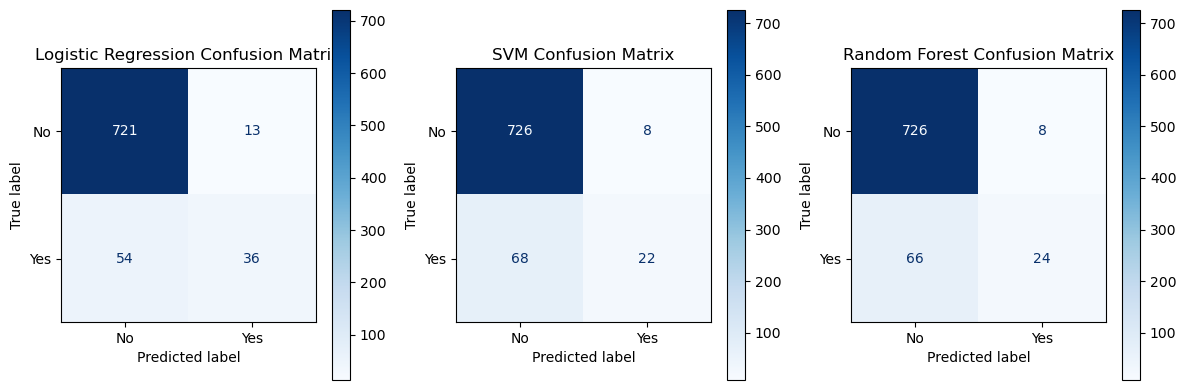

In [33]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Creating confusion matrices to display results more clearly

fig, axes = plt.subplots(1, 3, figsize=(12, 4))

for ax, (name, y_pred) in zip(axes, predictions.items()):
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["No", "Yes"])
    disp.plot(ax=ax, cmap="Blues")
    ax.set_title(f"{name} Confusion Matrix")

plt.tight_layout()
plt.show()

The logistic regression model provided the best results, since it had the highest accuracy, recall and F1-score. This means that it was the best model for identifying the target customers from the dataset. 